In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Prepare data for modeling
processed_df = df.copy()
le = LabelEncoder()

for col in ['sex', 'smoker', 'region']:
    processed_df[col] = le.fit_transform(processed_df[col])

X = processed_df.drop('charges', axis=1)
y = processed_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Data preprocessing complete.')
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')
display(processed_df.head())

Data preprocessing complete.
Training set size: 1069
Testing set size: 268


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [22]:
!pip install streamlit joblib scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 102.0 MB/s eta 0:00:00


### How to run the app

To run the application, execute the following command in your terminal:

```bash
streamlit run app.py
```

If you are using Google Colab and want to preview it here, you would typically need a tunneling service like `localtunnel` or `ngrok` since Colab doesn't expose local ports directly.

In [23]:
import joblib

# Save the best tuned model with the requested filename
joblib.dump(best_tuned_model, 'model.pkl')

# Save the feature names to ensure preprocessing matches
joblib.dump(X_advanced.columns.tolist(), 'feature_names.joblib')

print("Model saved as 'model.pkl' and feature metadata saved as 'feature_names.joblib'")

Model saved as 'model.pkl' and feature metadata saved as 'feature_names.joblib'


In [24]:
### Streamlit App Script (Updated to use model.pkl) ###

streamlit_code = """
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load model
model = joblib.load('model.pkl')
features = joblib.load('feature_names.joblib')

st.title('Insurance Charge Predictor')
st.write('Enter details below to estimate insurance costs.')

# User Inputs
age = st.number_input('Age', min_value=18, max_value=100, value=30)
bmi = st.number_input('BMI', min_value=10.0, max_value=60.0, value=25.0)
children = st.number_input('Number of Children', min_value=0, max_value=10, value=0)
sex = st.selectbox('Sex', ['male', 'female'])
smoker = st.selectbox('Smoker', ['yes', 'no'])
region = st.selectbox('Region', ['southwest', 'southeast', 'northwest', 'northeast'])

# Preprocessing mapping
sex_map = {'female': 0, 'male': 1}
smoker_map = {'no': 0, 'yes': 1}
region_map = {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}

# Create input dataframe
input_data = pd.DataFrame([{
    'age': age,
    'sex': sex_map[sex],
    'bmi': bmi,
    'children': children,
    'smoker': smoker_map[smoker],
    'region': region_map[region]
}])

# Apply Feature Engineering
input_data['is_obese'] = (input_data['bmi'] >= 30).astype(int)
input_data['smoker_bmi_interaction'] = input_data['smoker'] * input_data['bmi']
input_data['smoker_age_interaction'] = input_data['smoker'] * input_data['age']

# Reorder columns
input_data = input_data[features]

if st.button('Predict Charges'):
    prediction = model.predict(input_data)
    st.success(f'Estimated Insurance Charges: ${prediction[0]:,.2f}')
"""

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("Streamlit app script updated to use 'model.pkl'")

Streamlit app script updated to use 'model.pkl'


In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to explore
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

# Initialize the Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1)

print('Starting Hyperparameter Tuning (Grid Search)...')
grid_search.fit(X_train_adv, y_train_adv)

# Best parameters and score
print(f'Best Parameters: {grid_search.best_params_}')
best_tuned_model = grid_search.best_estimator_

# Evaluate on Test Set
y_tuned_pred = best_tuned_model.predict(X_test_adv)
tuned_mae = mean_absolute_error(y_test_adv, y_tuned_pred)
tuned_r2 = r2_score(y_test_adv, y_tuned_pred)

print('\nTuned Model Performance on Test Set:')
print(f'MAE: ${tuned_mae:.2f} (Previous best: $2531.59)')
print(f'R-squared: {tuned_r2:.44f}')

Starting Hyperparameter Tuning (Grid Search)...
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Tuned Model Performance on Test Set:
MAE: $2480.76 (Previous best: $2531.59)
R-squared: 0.90158912929887591314326300562242977321147919


/tmp/ipykernel_5744/1041352501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


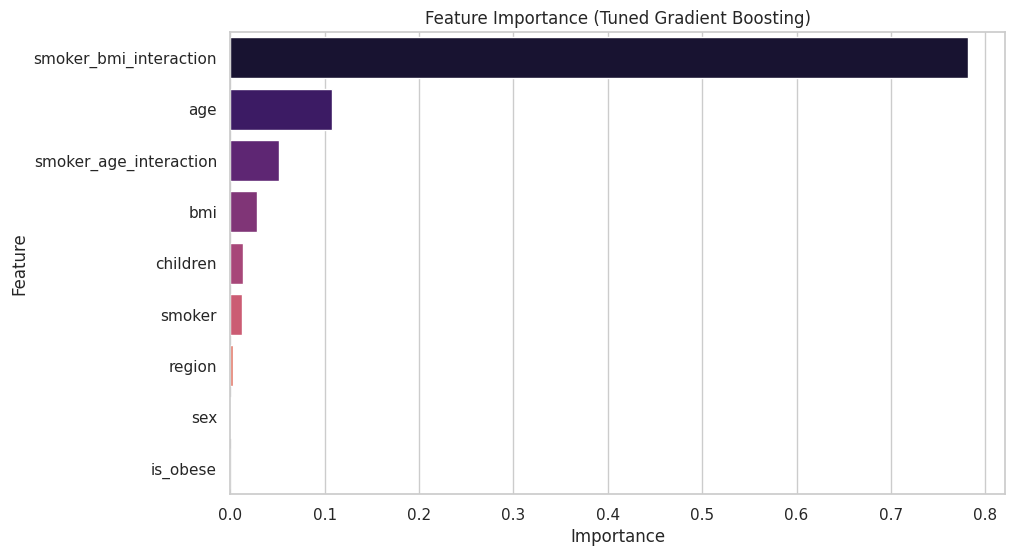

In [19]:
# Final Evaluation: Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = best_tuned_model.feature_importances_
feature_names = X_advanced.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Feature Importance (Tuned Gradient Boosting)')
plt.show()

Final Gradient Boosting Performance:
MAE: $2531.59
R-squared: 0.8982


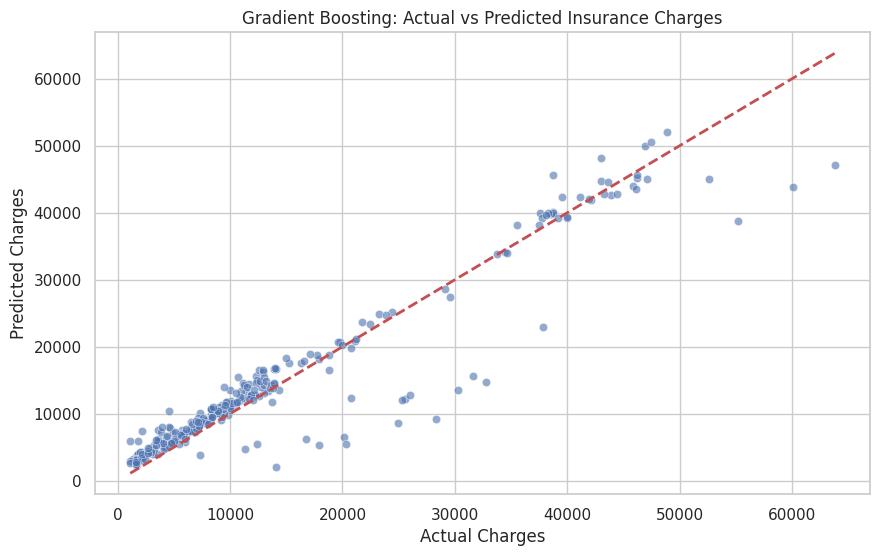

In [17]:
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Final model training
final_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train_adv, y_train_adv)

# Final predictions
y_final_pred = final_model.predict(X_test_adv)

# Final metrics
final_mae = mean_absolute_error(y_test_adv, y_final_pred)
final_r2 = r2_score(y_test_adv, y_final_pred)

print(f'Final Gradient Boosting Performance:')
print(f'MAE: ${final_mae:.2f}')
print(f'R-squared: {final_r2:.4f}')

# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_adv, y=y_final_pred, alpha=0.6)
plt.plot([y_test_adv.min(), y_test_adv.max()], [y_test_adv.min(), y_test_adv.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Gradient Boosting: Actual vs Predicted Insurance Charges')
plt.show()

In [15]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Define models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

print('Performing 5-Fold Cross-Validation...')
for name, model in models.items():
    # Use Negative Mean Absolute Error and convert to positive
    cv_scores = cross_val_score(model, X_advanced, y_advanced, cv=5, scoring='neg_mean_absolute_error')
    results[name] = -cv_scores.mean()
    print(f'{name}: Average MAE = {results[name]:.2f}')

# Identify the best model
best_model_name = min(results, key=results.get)
print(f'\nBest performing model based on CV: {best_model_name}')

Performing 5-Fold Cross-Validation...
Linear Regression: Average MAE = 2851.90
Random Forest: Average MAE = 2679.73
Gradient Boosting: Average MAE = 2507.92

Best performing model based on CV: Gradient Boosting


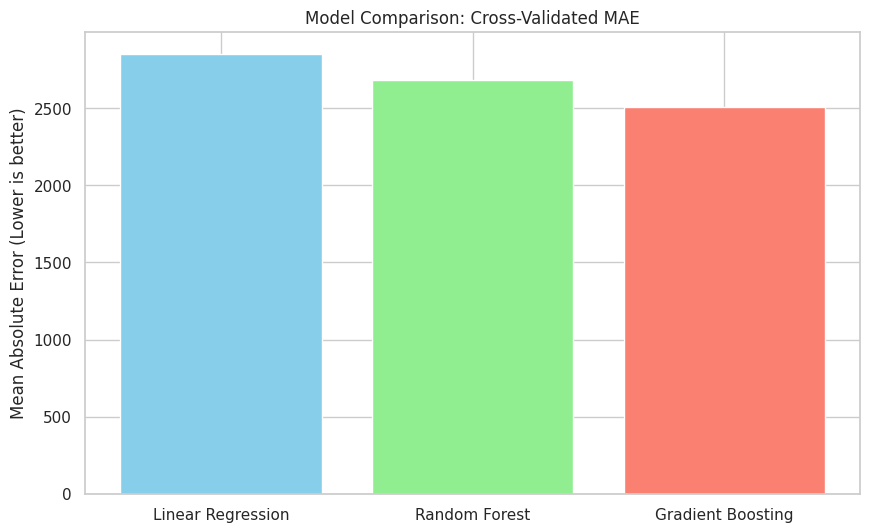

In [16]:
import matplotlib.pyplot as plt

# Visualize model comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Mean Absolute Error (Lower is better)')
plt.title('Model Comparison: Cross-Validated MAE')
plt.show()

In [12]:
# Feature Engineering
# 1. Create a binary feature for BMI >= 30 (Obese/Overweight status)
processed_df['is_obese'] = (processed_df['bmi'] >= 30).astype(int)

# 2. Create an interaction term between Smoker and BMI
# (Since smokers with high BMI often have much higher insurance costs)
processed_df['smoker_bmi_interaction'] = processed_df['smoker'] * processed_df['bmi']

# 3. Create an interaction term between Smoker and Age
processed_df['smoker_age_interaction'] = processed_df['smoker'] * processed_df['age']

print('Feature engineering complete. New features added: is_obese, smoker_bmi_interaction, smoker_age_interaction')
display(processed_df.head())

Feature engineering complete. New features added: is_obese, smoker_bmi_interaction, smoker_age_interaction


,age,sex,bmi,children,smoker,region,charges,is_obese,smoker_bmi_interaction,smoker_age_interaction
0,19,0,27.900,0,1,3,16884.92400,0,27.9,19
1,18,1,33.770,1,0,2,1725.55230,1,0.0,0
2,28,1,33.000,3,0,2,4449.46200,1,0.0,0
3,33,1,22.705,0,0,1,21984.47061,0,0.0,0
4,32,1,28.880,0,0,1,3866.85520,0,0.0,0


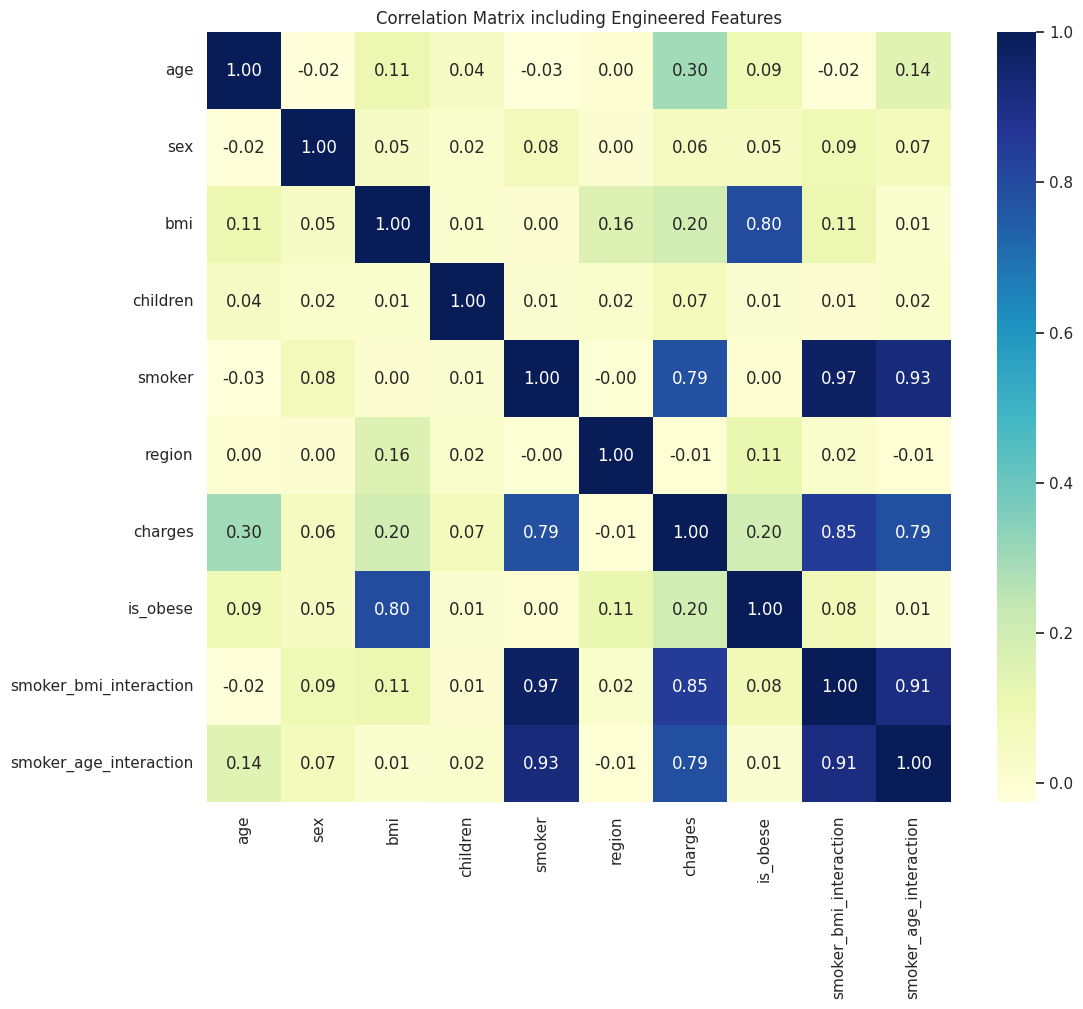

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize new correlations
plt.figure(figsize=(12, 10))
sns.heatmap(processed_df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Matrix including Engineered Features')
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Prepare features including the new engineered columns
X_advanced = processed_df.drop('charges', axis=1)
y_advanced = processed_df['charges']

# Split the updated data
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_advanced, y_advanced, test_size=0.2, random_state=42)

# Initialize and train the model with engineered features
model_adv = LinearRegression()
model_adv.fit(X_train_adv, y_train_adv)

# Make predictions
y_pred_adv = model_adv.predict(X_test_adv)

# Evaluate the model
mae_adv = mean_absolute_error(y_test_adv, y_pred_adv)
r2_adv = r2_score(y_test_adv, y_pred_adv)

print(f'Advanced Model Training Complete (with Engineered Features).')
print(f'New Mean Absolute Error: {mae_adv:.2f} (Baseline: 4182.35)')
print(f'New R-squared Score: {r2_adv:.2f} (Baseline: 0.81)')

Advanced Model Training Complete (with Engineered Features).
New Mean Absolute Error: 2816.94 (Baseline: 4182.35)
New R-squared Score: 0.89 (Baseline: 0.81)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy the dataframe for preprocessing
processed_df = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode categorical columns
for col in ['sex', 'smoker', 'region']:
    processed_df[col] = le.fit_transform(processed_df[col])

# Define features (X) and target (y)
X = processed_df.drop('charges', axis=1)
y = processed_df['charges']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preprocessing complete.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
processed_df.head()

Data preprocessing complete.
Training set shape: (1069, 6)
Testing set shape: (268, 6)


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


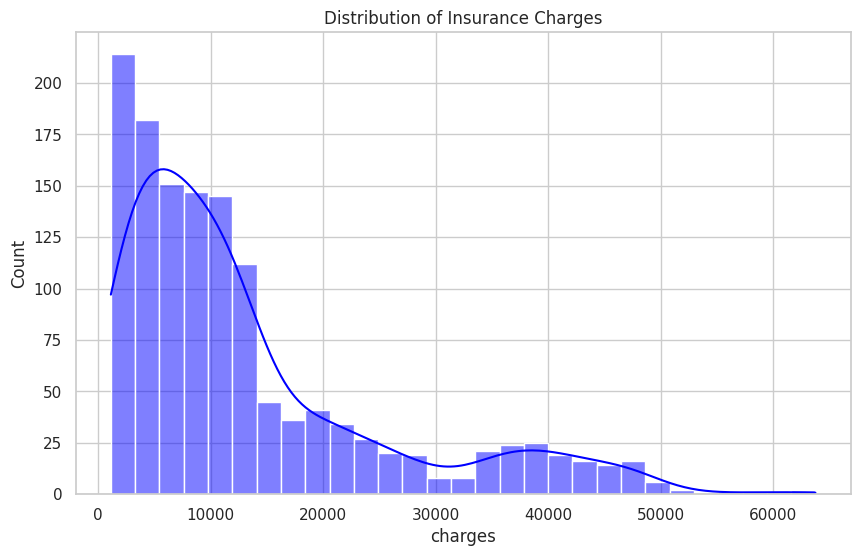

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style='whitegrid')

# 1. Distribution of Insurance Charges
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')
plt.show()

/tmp/ipykernel_5744/289425190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


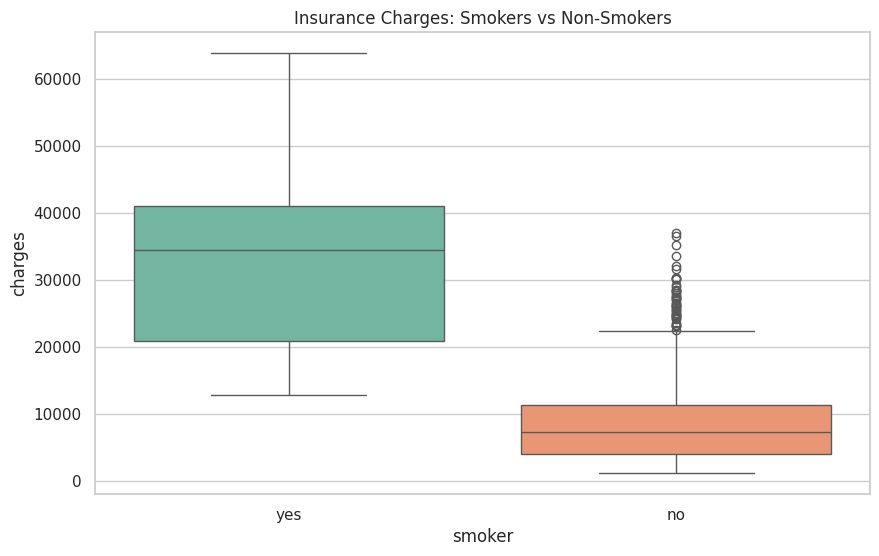

In [5]:
# 2. Impact of Smoking on Charges
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Insurance Charges: Smokers vs Non-Smokers')
plt.show()

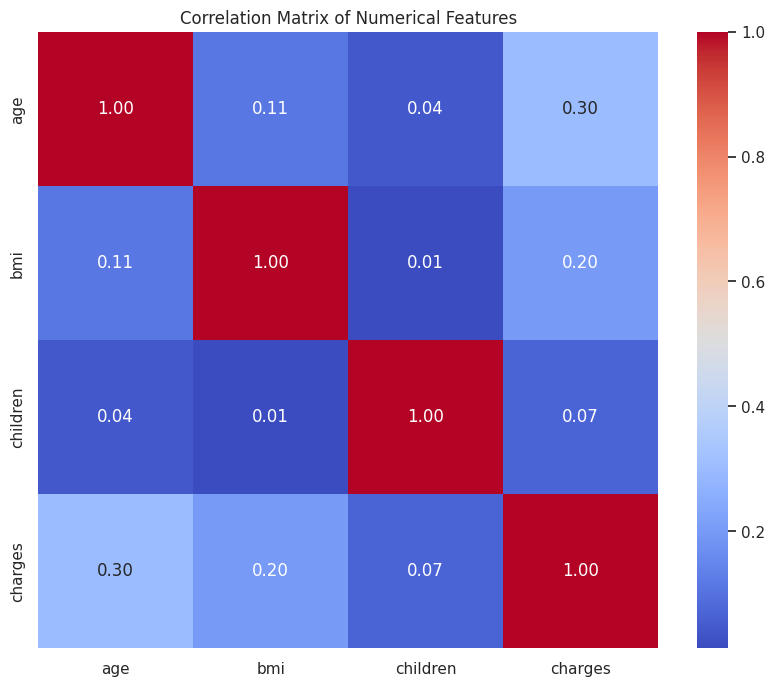

In [6]:
# 3. Correlation Heatmap for numerical variables
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

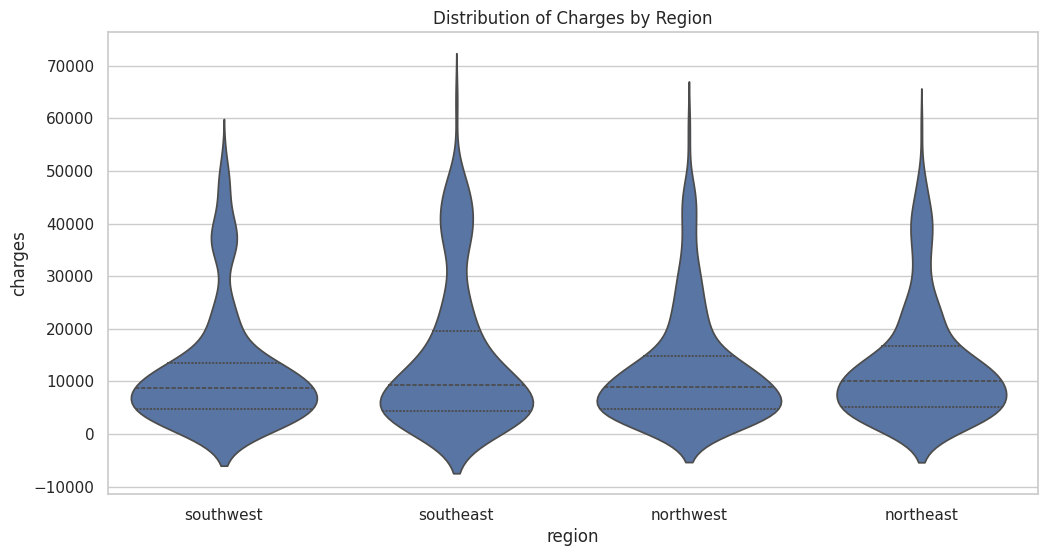

In [7]:
# 4. Charges by Region
plt.figure(figsize=(12, 6))
sns.violinplot(x='region', y='charges', data=df, inner='quartile')
plt.title('Distribution of Charges by Region')
plt.show()

In [2]:
# Check for missing values and duplicates
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

if df.duplicated().any():
    df = df.drop_duplicates()
    print("Duplicates removed.")

# Display data types and non-null counts
print("\nData Information:")
print(df.info())

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows: 1
Duplicates removed.

Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB
None


In [3]:
# Basic statistical summary for numerical columns
display(df.describe())

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [1]:
import pandas as pd

df = pd.read_csv('/content/insurance.csv')
display(df)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
